# Pixel novelty: inspect before extending

Novelty is mean squared pixel distance from the **previous grid’s mean image**. Every previous image has equal weight, including duplicates. The first choice is uniform; later choices maximize distance.

The pixel-novelty sections need no Torch. The observer sections require the `imagenet` extra and use the cached official ResNet18 checkpoint (downloaded if absent). Run cells in order: each strategy owns state, so create a fresh instance for every independent experiment.

In [1]:
from pathlib import Path
from random import Random
from datetime import datetime, timezone
import json

import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display

from automated_picbreeder.selection_strategies import NoveltySelectionStrategy
from automated_picbreeder.experiment import ExperimentSettings, run_experiment
from automated_picbreeder.experiment_reporting import contact_sheet

root = Path.cwd()
if not (root / "pyproject.toml").exists():
    root = root.parent
assert (root / "pyproject.toml").exists(), "Run from the repository or notebooks directory."

def show_mean(images):
    mean = np.stack(images).astype(np.float64).mean(axis=0)
    display(Image.fromarray(np.rint(mean).astype(np.uint8)).resize((192, 192)))
    return mean

def show_scores(images, decision):
    display(contact_sheet(images, list(range(len(images))), decision))
    print("candidate | raw pixel MSE | rank | seen before")
    for i, (raw, rank, seen) in enumerate(zip(
        decision.evaluation.values[:, 0], decision.scores,
        decision.evaluation.metadata["seen_before"], strict=True
    )):
        print(f"{i + 1:9d} | {raw:13.6f} | {rank:.3f} | {seen}")


## Known images

The reference contains four black images, four white images and a horizontal gradient. Its mean is close to grey. Inspect whether solid extremes score above structured images or noise. High pixel difference is not necessarily useful structure.

The reference image displayed below is rounded to bytes for display only; scoring keeps the unrounded floating-point mean.

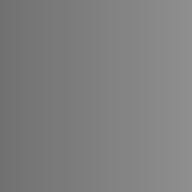

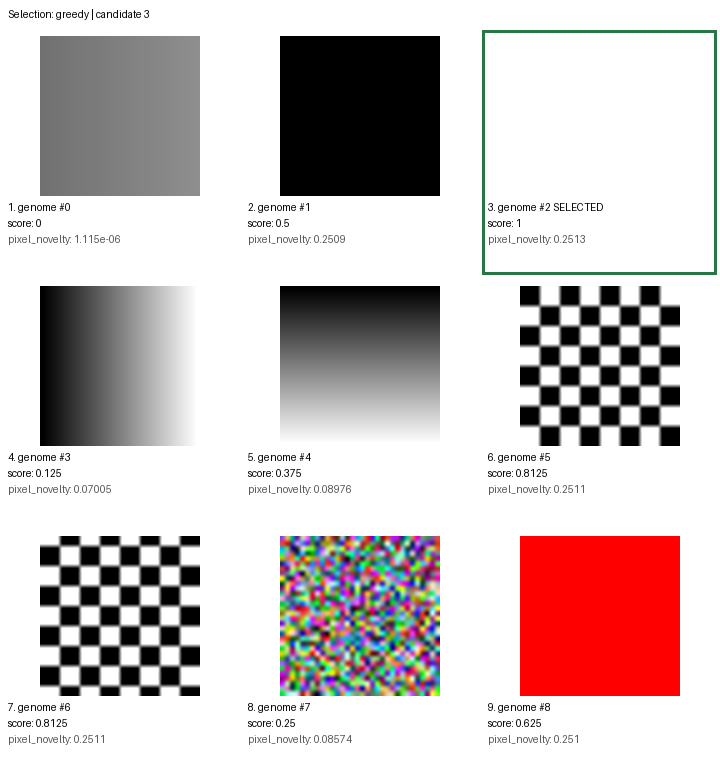

candidate | raw pixel MSE | rank | seen before
        1 |      0.000001 | 0.000 | False
        2 |      0.250890 | 0.500 | True
        3 |      0.251299 | 1.000 | True
        4 |      0.070055 | 0.125 | True
        5 |      0.089757 | 0.375 | False
        6 |      0.251095 | 0.812 | False
        7 |      0.251095 | 0.812 | False
        8 |      0.085745 | 0.250 | False
        9 |      0.251027 | 0.625 | False


In [2]:
size = 32
solid = lambda value: np.full((size, size, 3), value, dtype=np.uint8)
x = np.linspace(0, 255, size).astype(np.uint8)
gradient = np.repeat(np.tile(x, (size, 1))[:, :, None], 3, axis=2)
yy, xx = np.indices((size, size))
checker = np.repeat((((xx // 4 + yy // 4) % 2) * 255).astype(np.uint8)[:, :, None], 3, axis=2)
noise = np.random.default_rng(7).integers(0, 256, (size, size, 3), dtype=np.uint8)
reference = [solid(0)] * 4 + [solid(255)] * 4 + [gradient]
reference_mean = show_mean(reference)
strategy = NoveltySelectionStrategy()
rng = Random(7)
first = strategy.choose(reference, rng=rng)
assert first.mode == "random" and not first.evaluation.metadata["reference_available"]
candidates = [np.rint(reference_mean).astype(np.uint8), solid(0), solid(255),
              gradient, gradient.transpose(1, 0, 2).copy(), checker,
              np.roll(checker, 2, axis=0), noise, solid(0) + np.array([255, 0, 0], dtype=np.uint8)]
decision = strategy.choose(candidates, rng=rng)
show_scores(candidates, decision)
assert decision.position in (1, 2)
assert decision.evaluation.metadata["seen_before"][decision.position]


## Translation and colour sensitivity

With a checkerboard reference, shifting the same pattern changes its pixel distances. These comparisons show what this metric responds to, not perceptual novelty. This is a fresh strategy with its own reference.

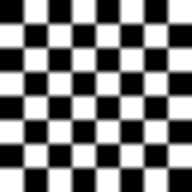

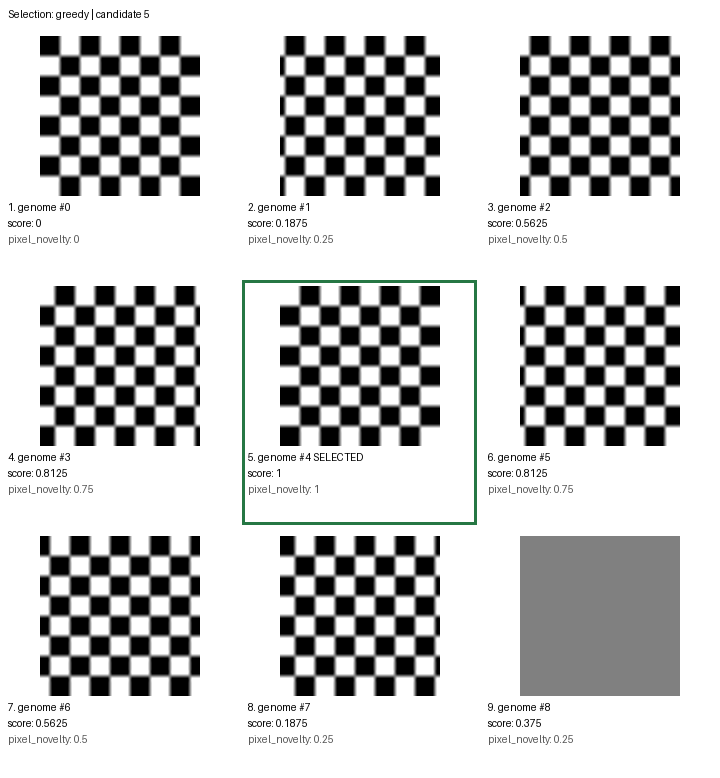

candidate | raw pixel MSE | rank | seen before
        1 |      0.000000 | 0.000 | True
        2 |      0.250000 | 0.188 | False
        3 |      0.500000 | 0.562 | False
        4 |      0.750000 | 0.812 | False
        5 |      1.000000 | 1.000 | False
        6 |      0.750000 | 0.812 | False
        7 |      0.500000 | 0.562 | False
        8 |      0.250000 | 0.188 | False
        9 |      0.250004 | 0.375 | False


In [3]:
shift_strategy = NoveltySelectionStrategy()
shift_rng = Random(7)
shift_strategy.choose([checker] * 9, rng=shift_rng)
shifted = [np.roll(checker, offset, axis=1) for offset in range(8)] + [solid(128)]
shift_decision = shift_strategy.choose(shifted, rng=shift_rng)
show_mean([checker] * 9)
show_scores(shifted, shift_decision)
assert shift_decision.evaluation.values[0, 0] == 0
assert shift_decision.evaluation.values[4, 0] == 1


## A short saved CPPN run

Use the shared runner with a **new strategy**. This four-decision run is an inspection example. Each execution creates a new output directory. Inspect the entire trajectory and the previous mean, not only the final selected image.

In [4]:
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S-%fZ")
output = root / "runs" / f"novelty-inspection-{stamp}"
settings = ExperimentSettings(seed=7, steps=4, size=32, checkpoint_every=2)
summary = run_experiment(selection_strategy=NoveltySelectionStrategy(),
                         output_dir=output, settings=settings)
print(output)
summary


Step 1/4: selected #0, random (score 0.5); 9 candidate presentations, 9 image evaluations
Step 2/4: selected #14, greedy (score 1); 18 candidate presentations, 18 image evaluations
Step 3/4: selected #19, greedy (score 1); 27 candidate presentations, 27 image evaluations
Step 4/4: selected #32, greedy (score 1); 36 candidate presentations, 36 image evaluations
/Users/caminmccluskey/projects/conjective/automated-picbreeder/runs/novelty-inspection-20260928T200823-511201Z


{'status': 'complete',
 'decisions': 4,
 'candidate_presentations': 36,
 'evaluated_images': 36,
 'unique_candidates': 33,
 'selected_id': 32,
 'selection_mode': 'greedy',
 'selected_score': 1.0,
 'elapsed_seconds': 0.28806749964132905}

Decision 1: no reference; uniform choice


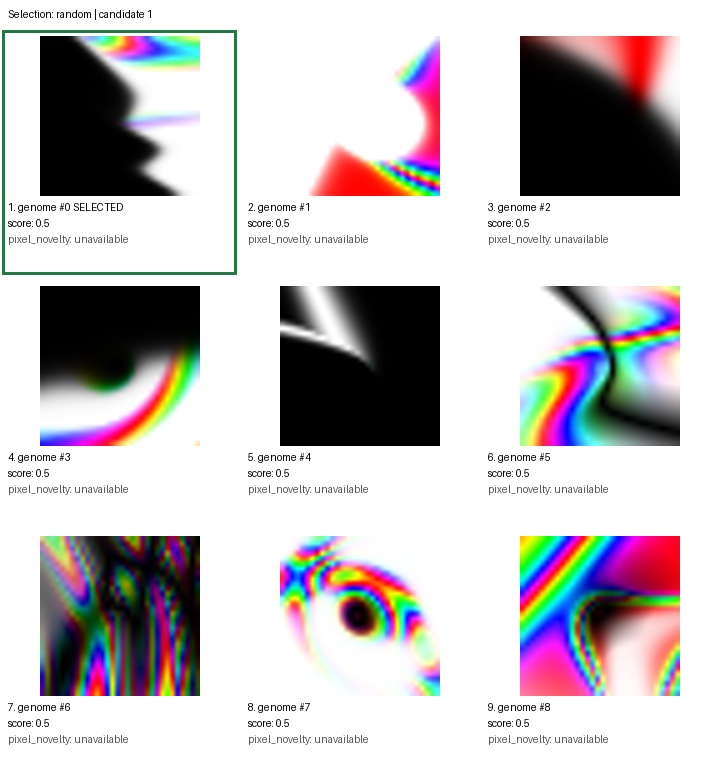

Decision 2: previous mean


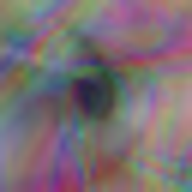

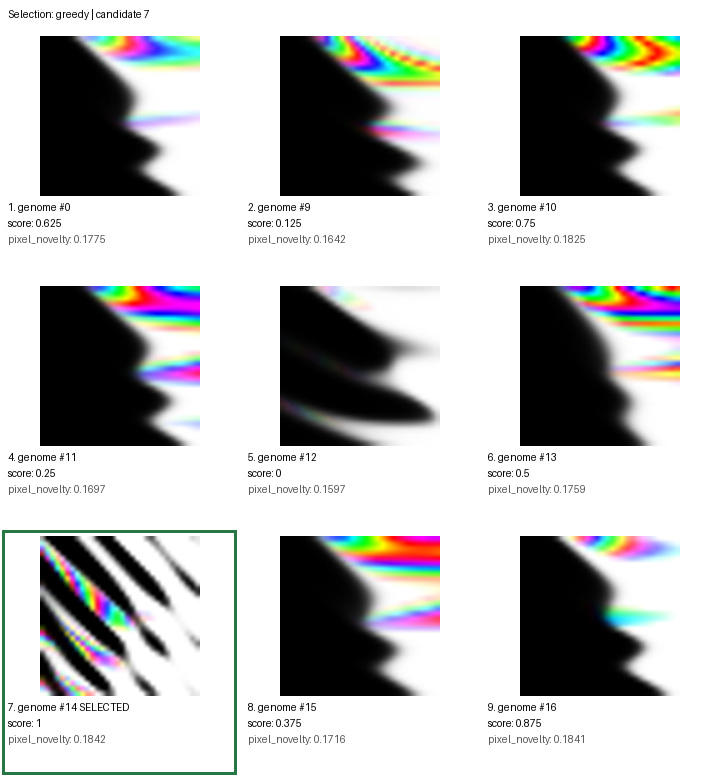

Decision 3: previous mean


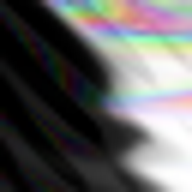

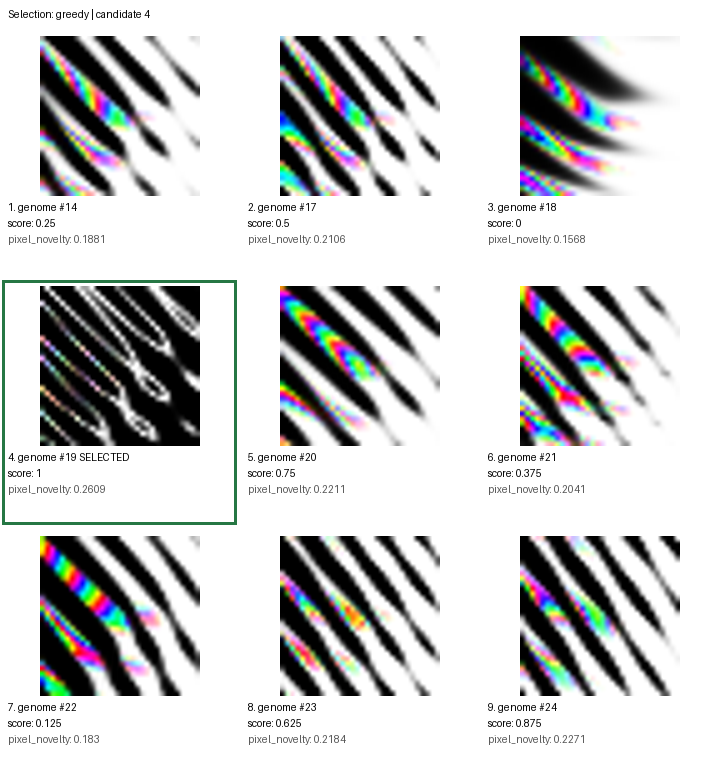

Decision 4: previous mean


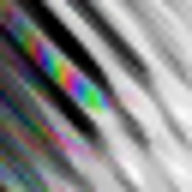

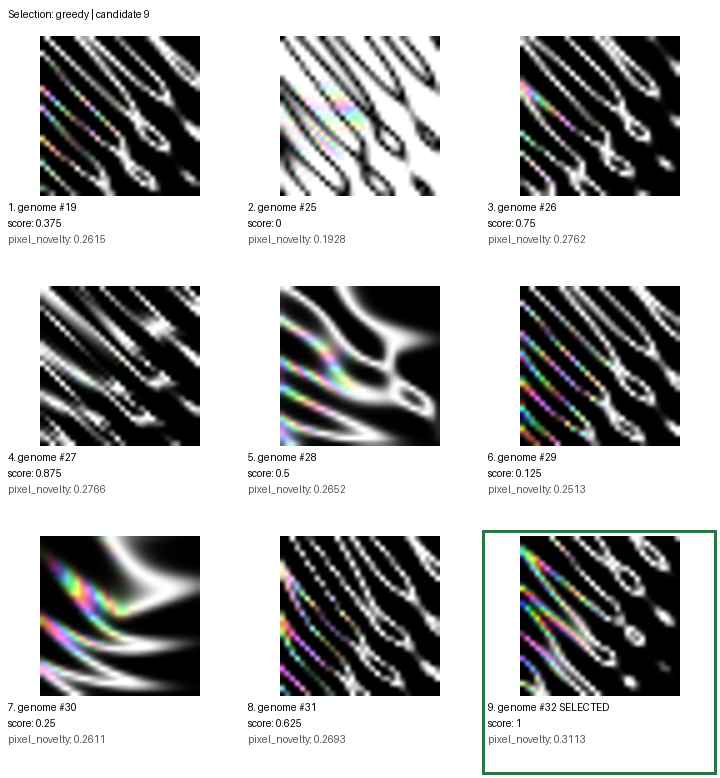

Saved image replay reproduces every choice and raw distance.


In [5]:
session = json.loads((output / "session.json").read_text())
records = {g["key"]: g for g in session["genomes"]}
selections = [e for e in session["events"] if e["action"] == "select"]
replay = NoveltySelectionStrategy()
replay_rng = Random(settings.resolved_selection_seed)
previous_images = None
for step, event in enumerate(selections):
    images = [np.array(Image.open(output / records[key]["image"])) for key in event["displayed"]]
    print(f"Decision {step + 1}: previous mean" if previous_images is not None
          else "Decision 1: no reference; uniform choice")
    if previous_images is not None:
        show_mean(previous_images)
    result = replay.choose(images, rng=replay_rng)
    assert result.position == event["position"]
    np.testing.assert_array_equal(result.evaluation.values, event["evaluation"]["values"])
    display(Image.open(output / "grids" / f"{step:06d}.png"))
    previous_images = images
assert len(records) == 9 + 8 * (settings.steps - 1)
assert summary["candidate_presentations"] == 9 * settings.steps
print("Saved image replay reproduces every choice and raw distance.")


The raw distance changes meaning with the previous mean; rank scores are only relative to each grid. Neither is an absolute interestingness scale. A parent can remain the furthest image from the average, so repeated selections and older patterns are allowed.

The next sections inspect the implemented observers.

## Matched observers: inspect predictions before training on the next grid

Both arms use the same architecture, masking task and head initialization. Only the backbone initialization differs. Each image has sixteen masked versions, and the reconstructed display assembles their hidden-tile predictions. A scalar masked MSE is computed from these pixels.

This is a short wiring/inspection exercise: **2 training updates of batch size 4 per decision**, instead of the strategy defaults of 20 updates and batch size 16. It is not a test of which initialization produces more interesting images. All nine reference images enter replay, deduplicated by exact original pixels; the current candidate grid is only admitted after scoring.

random — raw components and combined ranks


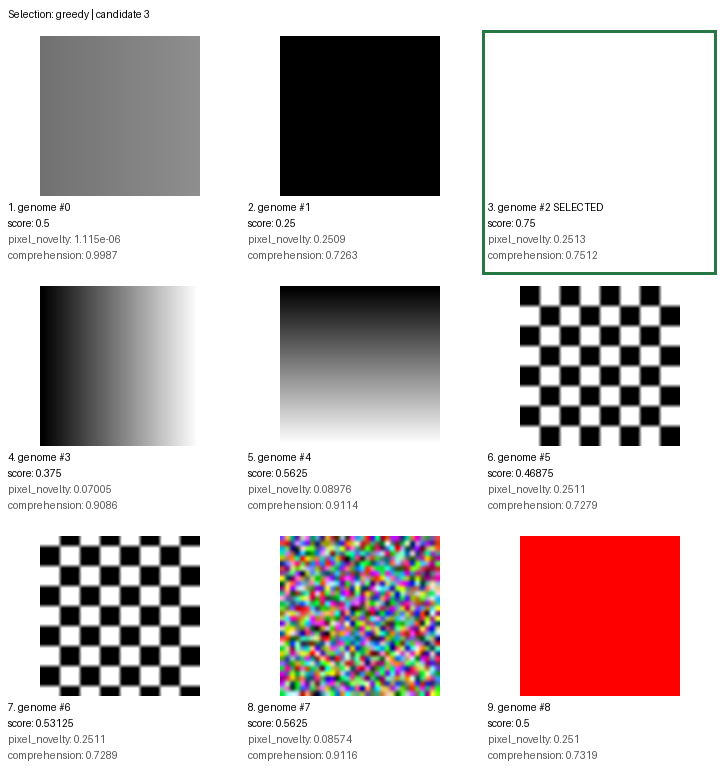

pre-update errors: [0.0013 0.2737 0.2488 0.0914 0.0886 0.2721 0.2711 0.0884 0.2681]
novelty ranks: [0.0, 0.5, 1.0, 0.125, 0.375, 0.8125, 0.8125, 0.25, 0.625]
comprehension ranks: [1.0, 0.0, 0.5, 0.625, 0.75, 0.125, 0.25, 0.875, 0.375]
replay images: 3 -> 9
training seconds: 0.058 optimizer updates: 2
imagenet — raw components and combined ranks


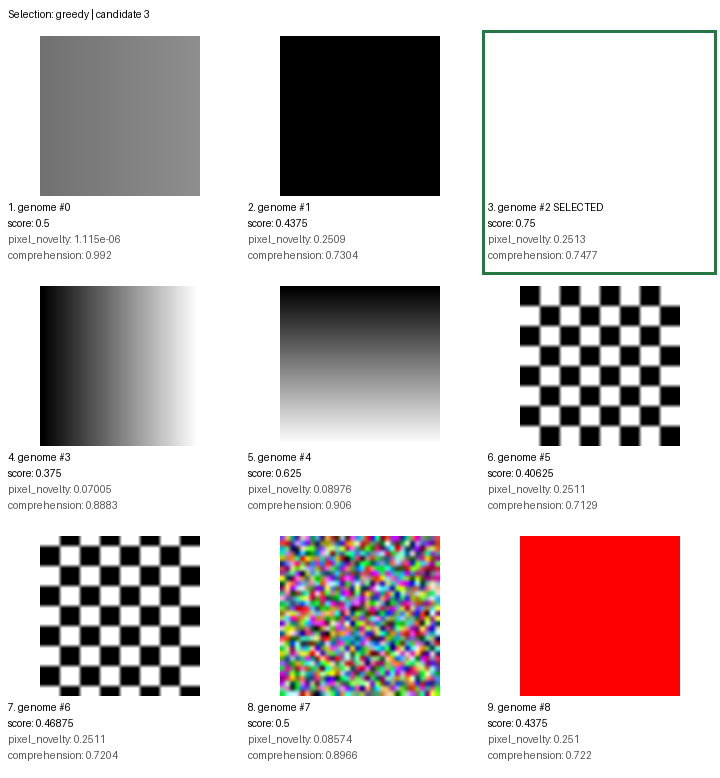

pre-update errors: [0.008  0.2696 0.2523 0.1117 0.094  0.2871 0.2796 0.1034 0.278 ]
novelty ranks: [0.0, 0.5, 1.0, 0.125, 0.375, 0.8125, 0.8125, 0.25, 0.625]
comprehension ranks: [1.0, 0.375, 0.5, 0.625, 0.875, 0.0, 0.125, 0.75, 0.25]
replay images: 3 -> 9
training seconds: 0.06 optimizer updates: 2


In [6]:
from automated_picbreeder.selection_strategies import NoveltyPredictabilitySelectionStrategy
from automated_picbreeder.image_predictability import masked_inputs
import torch

observer_runs = {}
for initialization in ("random", "imagenet"):
    combined = NoveltyPredictabilitySelectionStrategy(
        observer_initialization=initialization, comprehension_warmup_steps=0, training_steps=2, batch_size=4,
        cache_dir=root / ".cache" / "imagenet",
    )
    observer_rng = Random(7)
    first = combined.choose(reference, rng=observer_rng)
    # Inspection does not train or advance strategy state.
    state_before = combined.observer.state_hash()
    errors, reconstructed = combined.observer.predict(candidates)
    result = combined.choose(candidates, rng=observer_rng)
    assert result.evaluation.metadata["observer_state_before"] == state_before
    np.testing.assert_array_equal(errors, result.evaluation.metadata["masked_mse"])
    observer_runs[initialization] = (combined, first, result, reconstructed)
    print(initialization, "— raw components and combined ranks")
    display(contact_sheet(candidates, list(range(9)), result))
    meta = result.evaluation.metadata
    print("pre-update errors:", errors.round(4))
    print("novelty ranks:", meta["novelty_ranks"])
    print("comprehension ranks:", meta["comprehension_ranks"])
    print("replay images:", meta["replay_size_before"], "->", meta["replay_size_after"])
    print("training seconds:", round(meta["training_seconds"], 3),
          "optimizer updates:", meta["training"]["updates"])

assert observer_runs["random"][1].position == observer_runs["imagenet"][1].position
assert (observer_runs["random"][2].evaluation.metadata["update_seed"] ==
        observer_runs["imagenet"][2].evaluation.metadata["update_seed"])


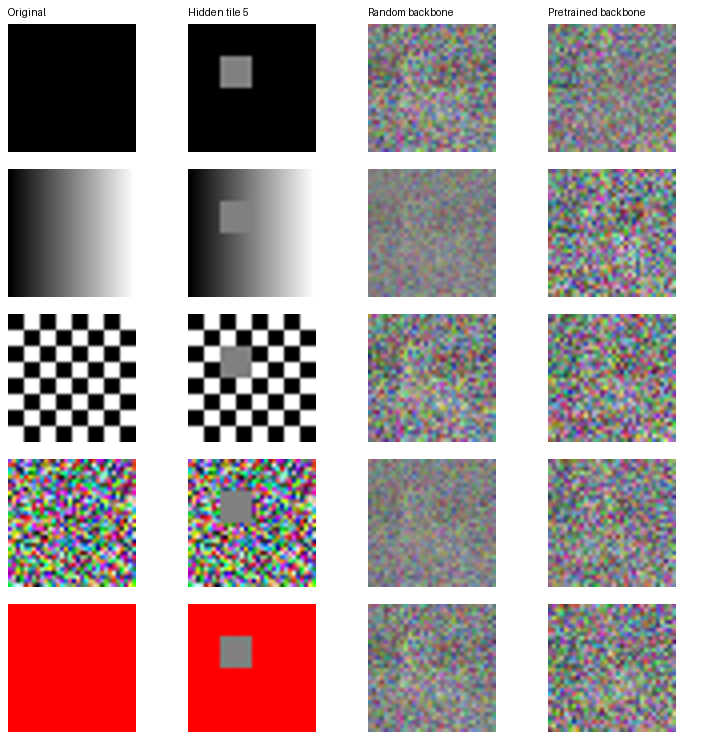

In [7]:
# Originals, one masked input (tile 5), and each observer's PRE-UPDATE mosaic.
canvas = Image.new("RGB", (4 * 180, 5 * 150), "white")
draw = ImageDraw.Draw(canvas)
for col, label in enumerate(("Original", "Hidden tile 5", "Random backbone", "Pretrained backbone")):
    draw.text((col * 180 + 8, 6), label, fill="black")
for row, candidate_index in enumerate((1, 3, 5, 7, 8)):
    image = candidates[candidate_index]
    target = observer_runs["random"][0].observer.prepare(image)
    _, visible = masked_inputs(target[None], torch.tensor([5]))
    masked = (target * visible[0] + .5 * (1 - visible[0])).permute(1, 2, 0).numpy()
    original = target.permute(1, 2, 0).numpy()
    samples = [original, masked, observer_runs["random"][3][candidate_index],
               observer_runs["imagenet"][3][candidate_index]]
    for col, pixels in enumerate(samples):
        tile = Image.fromarray(np.rint(np.clip(pixels, 0, 1) * 255).astype(np.uint8))
        canvas.paste(tile.resize((128, 128)), (col * 180 + 8, row * 145 + 24))
display(canvas)
canvas.save(output / "observer-predictions.png")


This two-grid inspection explicitly disables comprehension warm-up. Full runs default to ten completed decisions before comprehension influences selection. Scores shown above come from the model **before** that candidate grid was trained on. The model has since advanced, so asking it to predict again would produce different values. Inspect the saved pre-update errors instead.

For a full run, pass a fresh `NoveltyPredictabilitySelectionStrategy(observer_initialization="random")` or `observer_initialization="imagenet"` to the existing runner. The first decision is uniform, with unavailable comprehension. Every later decision records raw measurements, ranks, model hashes, update seeds, replay sizes and costs. The usual session checkpoints remain audit records; they are not resumable model checkpoints.